# Employer Reputation Prediction Analysis

This notebook investigates which numerical QS score indicators help predict `Employer_Reputation_Score`. The analysis uses complete-case data, train/validation/test splitting, multiple linear regression, validation-based forward selection, and a simple final model comparison.


## 1. Load and inspect dataset


In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_csv("QS_DATASET.csv", encoding="latin1")
df.head()


,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,...,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score
0,1,1,Massachusetts Institute of Technology (MIT),United States,Americas,M,CO,VH,B,100.0,...,100,86.8,143,96.0,58,100.0,8,99.0,15=,100
1,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,...,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5
2,3,3,University of Oxford,United Kingdom,Europe,L,FC,VH,A,100.0,...,120,97.7,73,100.0,1,100.0,3,85.0,126,96.9
3,4,4,Harvard University,United States,Americas,L,FC,VH,B,100.0,...,269,69.0,215,99.6,5,100.0,1,84.4,130,96.8
4,5,2,University of Cambridge,United Kingdom,Europe,L,FC,VH,A,100.0,...,73,94.8,98,99.3,10,100.0,5,84.8,127=,96.7


In [129]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
for col in df.columns:
    print(col)


Dataset shape: (1503, 28)

Column names:
RANK_2025
RANK_2024
Institution_Name
Location
Region
SIZE
FOCUS
RES.
STATUS
Academic_Reputation_Score
Academic_Reputation_Rank
Employer_Reputation_Score
Employer_Reputation_Rank
Faculty_Student_Score
Faculty_Student_Rank
Citations_per_Faculty_Score
Citations_per_Faculty_Rank
International_Faculty_Score
International_Faculty_Rank
International_Students_Score
International_Students_Rank
International_Research_Network_Score
International_Research_Network_Rank
Employment_Outcomes_Score
Employment_Outcomes_Rank
Sustainability_Score
Sustainability_Rank
Overall_Score


In [130]:
df.info()

missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   RANK_2025                             1503 non-null   object 
 1   RANK_2024                             1482 non-null   object 
 2   Institution_Name                      1503 non-null   object 
 3   Location                              1503 non-null   object 
 4   Region                                1503 non-null   object 
 5   SIZE                                  1503 non-null   object 
 6   FOCUS                                 1503 non-null   object 
 7   RES.                                  1503 non-null   object 
 8   STATUS                                1466 non-null   object 
 9   Academic_Reputation_Score             1503 non-null   float64
 10  Academic_Reputation_Rank              1503 non-null   object 
 11  Employer_Reputati

Overall_Score                           902
International_Faculty_Score             100
International_Faculty_Rank              100
International_Students_Score             58
International_Students_Rank              58
STATUS                                   37
RANK_2024                                21
Sustainability_Score                     19
Sustainability_Rank                      19
International_Research_Network_Score      1
International_Research_Network_Rank       1
dtype: int64

## 2. Data audit and variable classification

`Employer_Reputation_Score` is the dependent variable. The candidate predictors are limited to numerical QS score columns. Rank columns, identifiers, institutional descriptors, and `Overall_Score` are excluded from modelling.


In [131]:
target = "Employer_Reputation_Score"

score_candidates = [
    "Academic_Reputation_Score",
    "Faculty_Student_Score",
    "Citations_per_Faculty_Score",
    "International_Faculty_Score",
    "International_Students_Score",
    "International_Research_Network_Score",
    "Employment_Outcomes_Score",
    "Sustainability_Score"
]

excluded_columns = [
    "RANK_2025",
    "RANK_2024",
    "Institution_Name",
    "Location",
    "Region",
    "SIZE",
    "FOCUS",
    "RES.",
    "STATUS",
    "Academic_Reputation_Rank",
    "Employer_Reputation_Rank",
    "Faculty_Student_Rank",
    "Citations_per_Faculty_Rank",
    "International_Faculty_Rank",
    "International_Students_Rank",
    "International_Research_Network_Rank",
    "Employment_Outcomes_Rank",
    "Sustainability_Rank",
    "Overall_Score"
]

print("Target:")
print(target)

print("\nNumerical score candidate predictors:")
for col in score_candidates:
    print("-", col)

print("\nColumns excluded from modelling:")
for col in excluded_columns:
    print("-", col)


Target:
Employer_Reputation_Score

Numerical score candidate predictors:
- Academic_Reputation_Score
- Faculty_Student_Score
- Citations_per_Faculty_Score
- International_Faculty_Score
- International_Students_Score
- International_Research_Network_Score
- Employment_Outcomes_Score
- Sustainability_Score

Columns excluded from modelling:
- RANK_2025
- RANK_2024
- Institution_Name
- Location
- Region
- SIZE
- FOCUS
- RES.
- STATUS
- Academic_Reputation_Rank
- Employer_Reputation_Rank
- Faculty_Student_Rank
- Citations_per_Faculty_Rank
- International_Faculty_Rank
- International_Students_Rank
- International_Research_Network_Rank
- Employment_Outcomes_Rank
- Sustainability_Rank
- Overall_Score


In [132]:
modelling_columns = [target] + score_candidates

column_audit_df = pd.DataFrame({
    "Column": df.columns,
    "Data_type": df.dtypes.astype(str).values,
    "Missing_count": df.isnull().sum().values,
    "Used_for_modelling": [col in modelling_columns for col in df.columns],
    "Excluded_from_modelling": [col in excluded_columns for col in df.columns]
})

column_audit_df


,Column,Data_type,Missing_count,Used_for_modelling,Excluded_from_modelling
0,RANK_2025,object,0,False,True
1,RANK_2024,object,21,False,True
2,Institution_Name,object,0,False,True
3,Location,object,0,False,True
4,Region,object,0,False,True
5,SIZE,object,0,False,True
6,FOCUS,object,0,False,True
7,RES.,object,0,False,True
8,STATUS,object,37,False,True
9,Academic_Reputation_Score,float64,0,True,False


### Missing value handling

Complete-case analysis is used only on the target and numerical score candidate variables.


In [133]:
score_missing = df[modelling_columns].isnull().sum().sort_values(ascending=False)
score_missing


International_Faculty_Score             100
International_Students_Score             58
Sustainability_Score                     19
International_Research_Network_Score      1
Employer_Reputation_Score                 0
Academic_Reputation_Score                 0
Faculty_Student_Score                     0
Citations_per_Faculty_Score               0
Employment_Outcomes_Score                 0
dtype: int64

In [134]:
score_complete_df = df[modelling_columns].dropna()
model_df = score_complete_df.copy()

print("Original dataset rows:", df.shape[0])
print("Complete-case modelling rows:", model_df.shape[0])
print("Rows removed:", df.shape[0] - model_df.shape[0])


Original dataset rows: 1503
Complete-case modelling rows: 1382
Rows removed: 121


## 3. Exploratory data analysis for numerical score variables

This section explores the target variable and its relationships with the numerical QS score candidate predictors.


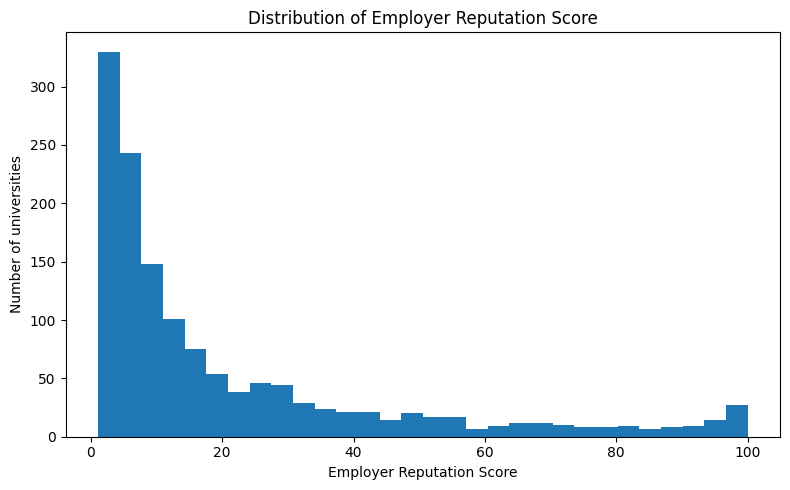

In [135]:
plt.figure(figsize=(8, 5))
plt.hist(model_df[target], bins=30)
plt.xlabel("Employer Reputation Score")
plt.ylabel("Number of universities")
plt.title("Distribution of Employer Reputation Score")
plt.tight_layout()
plt.show()


In [136]:
target_summary = model_df[target].describe()
target_summary


count    1382.000000
mean       20.865991
std        24.412349
min         1.100000
25%         4.500000
50%        10.300000
75%        27.675000
max       100.000000
Name: Employer_Reputation_Score, dtype: float64

In [137]:
score_summary_df = model_df[score_candidates].describe().T
score_summary_df


,count,mean,std,min,25%,50%,75%,max
Academic_Reputation_Score,1382.0,21.355427,22.932436,1.3,6.525,11.85,25.275,100.0
Faculty_Student_Score,1382.0,28.382851,27.596416,1.2,7.500,16.50,41.250,100.0
Citations_per_Faculty_Score,1382.0,24.574819,28.250027,1.0,3.000,10.95,39.300,100.0
International_Faculty_Score,1382.0,30.964834,34.480371,1.0,4.200,12.60,52.575,100.0
International_Students_Score,1382.0,26.338712,31.452102,1.0,3.000,10.40,40.800,100.0
International_Research_Network_Score,1382.0,51.667438,29.606387,1.0,24.550,53.30,78.200,100.0
Employment_Outcomes_Score,1382.0,24.638857,27.692307,1.2,4.200,12.55,34.975,100.0
Sustainability_Score,1382.0,25.891172,31.605317,1.0,1.500,8.35,44.600,100.0


In [138]:
score_corr = model_df[[target] + score_candidates].corr()[target].drop(target)
score_corr_sorted = score_corr.reindex(score_corr.abs().sort_values(ascending=False).index)
score_corr_sorted


Academic_Reputation_Score               0.855657
Employment_Outcomes_Score               0.653987
Sustainability_Score                    0.594281
International_Research_Network_Score    0.422029
Citations_per_Faculty_Score             0.389707
International_Students_Score            0.349212
Faculty_Student_Score                   0.340439
International_Faculty_Score             0.327386
Name: Employer_Reputation_Score, dtype: float64

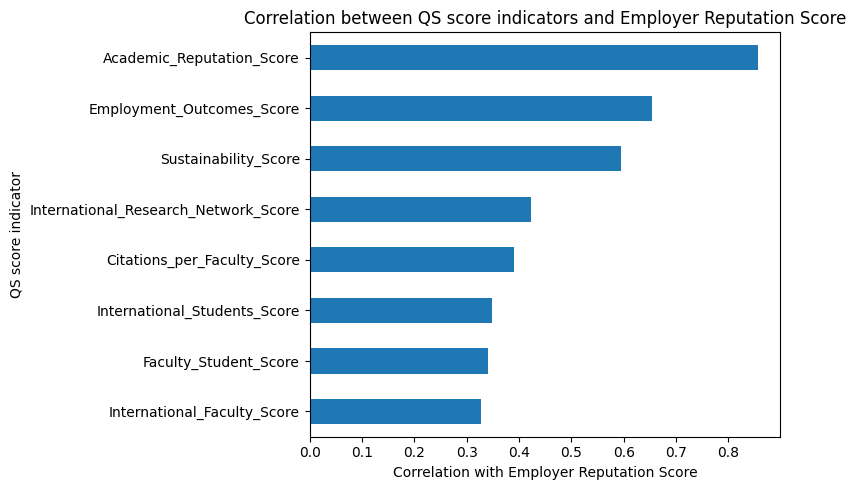

In [139]:
plt.figure(figsize=(8, 5))
score_corr_sorted.sort_values().plot(kind="barh")
plt.xlabel("Correlation with Employer Reputation Score")
plt.ylabel("QS score indicator")
plt.title("Correlation between QS score indicators and Employer Reputation Score")
plt.tight_layout()
plt.show()


### Scatter plots for highly correlated score indicators

These plots check whether the strongest exploratory relationships appear approximately linear and whether outliers may influence the regression models.


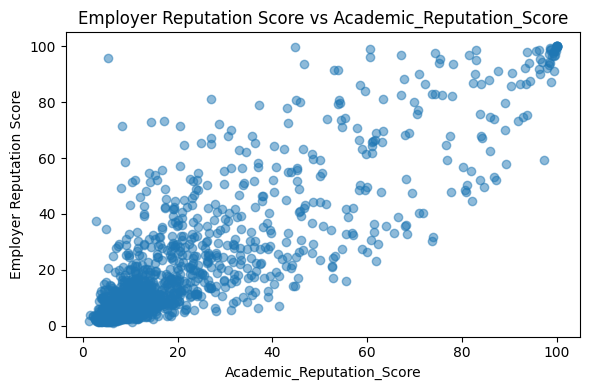

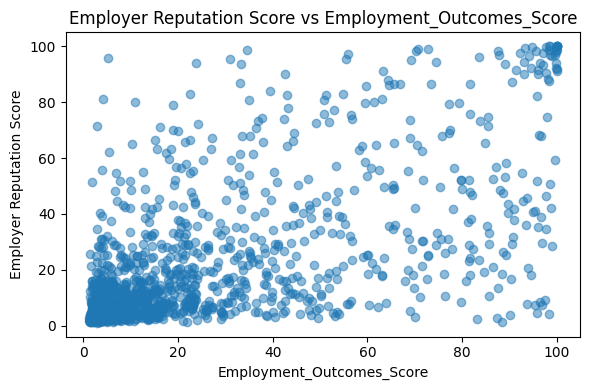

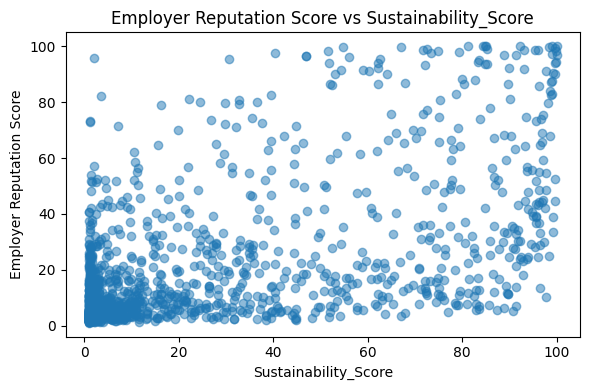

In [140]:
top_scatter_features = score_corr_sorted.head(3).index.tolist()

for feature in top_scatter_features:
    plt.figure(figsize=(6, 4))
    plt.scatter(model_df[feature], model_df[target], alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel("Employer Reputation Score")
    plt.title(f"Employer Reputation Score vs {feature}")
    plt.tight_layout()
    plt.show()


### EDA observations

The numerical score variables show different levels of association with `Employer_Reputation_Score`. These exploratory results help motivate the baseline model and later score-only model comparison, but final model choice is based on validation and test performance.


## 4. Train, validation, and test split

The complete-case modelling dataset is split into 60% training, 20% validation, and 20% test data using `random_state=42`.


In [141]:
train_df, temp_df = train_test_split(
    model_df,
    test_size=0.4,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

split_summary_df = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Test"],
    "Rows": [train_df.shape[0], val_df.shape[0], test_df.shape[0]],
    "Percentage": [
        train_df.shape[0] / model_df.shape[0] * 100,
        val_df.shape[0] / model_df.shape[0] * 100,
        test_df.shape[0] / model_df.shape[0] * 100
    ]
})

split_summary_df


,Dataset,Rows,Percentage
0,Training,829,59.985528
1,Validation,276,19.971056
2,Test,277,20.043415


## 5. Model evaluation helper functions


In [142]:
def adjusted_r2_score(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


def evaluate_regression_model(model, X, y, dataset_name, model_name):
    predictions = model.predict(X)
    
    r2 = r2_score(y, predictions)
    mae = mean_absolute_error(y, predictions)
    rmse = np.sqrt(mean_squared_error(y, predictions))
    adj_r2 = adjusted_r2_score(r2, X.shape[0], X.shape[1])
    
    return {
        "Model": model_name,
        "Dataset": dataset_name,
        "R2": r2,
        "Adjusted_R2": adj_r2,
        "MAE": mae,
        "RMSE": rmse,
        "n": X.shape[0],
        "p": X.shape[1]
    }


def fit_and_evaluate_model(features, model_name):
    model = LinearRegression()
    model.fit(train_df[features], train_df[target])
    
    results = []
    for dataset_name, data in [
        ("Training", train_df),
        ("Validation", val_df),
        ("Test", test_df)
    ]:
        results.append(
            evaluate_regression_model(
                model,
                data[features],
                data[target],
                dataset_name,
                model_name
            )
        )
    
    return model, pd.DataFrame(results)


## 6. Baseline linear regression using Academic_Reputation_Score


In [143]:
baseline_features = ["Academic_Reputation_Score"]

baseline_model, baseline_results_df = fit_and_evaluate_model(
    baseline_features,
    "Baseline: Academic Reputation only"
)

baseline_results_df


,Model,Dataset,R2,Adjusted_R2,MAE,RMSE,n,p
0,Baseline: Academic Reputation only,Training,0.753621,0.753323,8.355847,12.720477,829,1
1,Baseline: Academic Reputation only,Validation,0.625144,0.623776,9.087372,13.843540,276,1
2,Baseline: Academic Reputation only,Test,0.751487,0.750583,7.611190,11.020919,277,1


## 7. Score-only full multiple linear regression


In [144]:
score_features = score_candidates.copy()

score_full_model, score_full_results_df = fit_and_evaluate_model(
    score_features,
    "Score-only full model"
)

score_full_results_df


,Model,Dataset,R2,Adjusted_R2,MAE,RMSE,n,p
0,Score-only full model,Training,0.775457,0.773266,8.149784,12.143719,829,8
1,Score-only full model,Validation,0.654489,0.644136,8.680923,13.290641,276,8
2,Score-only full model,Test,0.777055,0.770399,7.246970,10.438597,277,8


## 8. VIF diagnostic for score candidates

Variance Inflation Factor (VIF) is used as an optional diagnostic for multicollinearity among the numerical score candidate predictors.


In [145]:
def calculate_vif(data, features):
    vif_results = []
    
    for feature in features:
        other_features = [col for col in features if col != feature]
        X_other = data[other_features]
        y_feature = data[feature]
        
        model = LinearRegression()
        model.fit(X_other, y_feature)
        
        r2 = model.score(X_other, y_feature)
        vif = 1 / (1 - r2) if r2 < 1 else np.inf
        
        vif_results.append({
            "Feature": feature,
            "VIF": vif
        })
    
    return pd.DataFrame(vif_results).sort_values("VIF", ascending=False)


score_vif_df = calculate_vif(train_df, score_features)
score_vif_df


,Feature,VIF
0,Academic_Reputation_Score,3.503901
7,Sustainability_Score,2.950120
5,International_Research_Network_Score,2.171433
3,International_Faculty_Score,2.157576
6,Employment_Outcomes_Score,2.069179
4,International_Students_Score,2.009439
2,Citations_per_Faculty_Score,1.596824
1,Faculty_Student_Score,1.197829


## 9. Validation-based forward selection

The reduced model is developed using forward selection. Starting from no predictors, candidate score features are added one at a time if they improve validation RMSE.


In [146]:
def forward_selection(train_data, val_data, candidate_features, target, min_improvement=0.01):
    selected_features = []
    remaining_features = candidate_features.copy()
    
    best_val_rmse = np.inf
    selection_history = []
    
    while remaining_features:
        trial_results = []
        
        for feature in remaining_features:
            trial_features = selected_features + [feature]
            
            model = LinearRegression()
            model.fit(train_data[trial_features], train_data[target])
            
            val_predictions = model.predict(val_data[trial_features])
            val_rmse = np.sqrt(mean_squared_error(val_data[target], val_predictions))
            val_r2 = r2_score(val_data[target], val_predictions)
            
            trial_results.append({
                "Feature_added": feature,
                "Features": trial_features,
                "Validation_RMSE": val_rmse,
                "Validation_R2": val_r2
            })
        
        trial_results_df = pd.DataFrame(trial_results).sort_values("Validation_RMSE")
        best_trial = trial_results_df.iloc[0]
        
        improvement = best_val_rmse - best_trial["Validation_RMSE"]
        
        if improvement > min_improvement:
            selected_features = best_trial["Features"]
            remaining_features.remove(best_trial["Feature_added"])
            best_val_rmse = best_trial["Validation_RMSE"]
            
            selection_history.append({
                "Step": len(selected_features),
                "Added_feature": best_trial["Feature_added"],
                "Validation_RMSE": best_trial["Validation_RMSE"],
                "Validation_R2": best_trial["Validation_R2"],
                "Improvement": improvement
            })
        else:
            break
    
    return selected_features, pd.DataFrame(selection_history)


selected_score_features, score_selection_history = forward_selection(
    train_df,
    val_df,
    score_candidates,
    target
)

print("Selected score features:")
for feature in selected_score_features:
    print("-", feature)

score_selection_history


Selected score features:
- Academic_Reputation_Score
- International_Research_Network_Score
- Employment_Outcomes_Score
- Sustainability_Score
- Faculty_Student_Score


,Step,Added_feature,Validation_RMSE,Validation_R2,Improvement
0,1,Academic_Reputation_Score,13.843540,0.625144,inf
1,2,International_Research_Network_Score,13.589102,0.638796,0.254438
2,3,Employment_Outcomes_Score,13.301679,0.653915,0.287423
3,4,Sustainability_Score,13.243299,0.656946,0.058380
4,5,Faculty_Student_Score,13.227204,0.657779,0.016095


## 10. Reduced score model


In [147]:
reduced_score_features = selected_score_features

reduced_score_model, reduced_score_results_df = fit_and_evaluate_model(
    reduced_score_features,
    "Reduced score model"
)

reduced_score_results_df


,Model,Dataset,R2,Adjusted_R2,MAE,RMSE,n,p
0,Reduced score model,Training,0.772579,0.771197,8.172770,12.221304,829,5
1,Reduced score model,Validation,0.657779,0.651442,8.610611,13.227204,276,5
2,Reduced score model,Test,0.777335,0.773227,7.231539,10.432029,277,5


## 11. Final model comparison

The final comparison includes only the baseline model, the score-only full model, and the reduced score model.


In [148]:
model_comparison_df = pd.concat(
    [
        baseline_results_df,
        score_full_results_df,
        reduced_score_results_df
    ],
    ignore_index=True
)

model_comparison_df = model_comparison_df[
    [
        "Model",
        "Dataset",
        "R2",
        "Adjusted_R2",
        "MAE",
        "RMSE",
        "n",
        "p"
    ]
].sort_values(["Dataset", "RMSE"]).reset_index(drop=True)

model_comparison_df


,Model,Dataset,R2,Adjusted_R2,MAE,RMSE,n,p
0,Reduced score model,Test,0.777335,0.773227,7.231539,10.432029,277,5
1,Score-only full model,Test,0.777055,0.770399,7.246970,10.438597,277,8
2,Baseline: Academic Reputation only,Test,0.751487,0.750583,7.611190,11.020919,277,1
3,Score-only full model,Training,0.775457,0.773266,8.149784,12.143719,829,8
4,Reduced score model,Training,0.772579,0.771197,8.172770,12.221304,829,5
5,Baseline: Academic Reputation only,Training,0.753621,0.753323,8.355847,12.720477,829,1
6,Reduced score model,Validation,0.657779,0.651442,8.610611,13.227204,276,5
7,Score-only full model,Validation,0.654489,0.644136,8.680923,13.290641,276,8
8,Baseline: Academic Reputation only,Validation,0.625144,0.623776,9.087372,13.843540,276,1


## 12. Final model interpretation

The reduced score model was selected for interpretation because it achieved similar test performance to the full score-only model while using fewer predictors. This section examines the model coefficients and prediction errors.

In [149]:
reduced_coefficients_df = pd.DataFrame({
    "Feature": reduced_score_features,
    "Coefficient": reduced_score_model.coef_
}).sort_values("Coefficient", ascending=False)

reduced_coefficients_df

,Feature,Coefficient
0,Academic_Reputation_Score,0.891316
2,Employment_Outcomes_Score,0.110580
4,Faculty_Student_Score,0.027301
3,Sustainability_Score,0.026496
1,International_Research_Network_Score,-0.123892


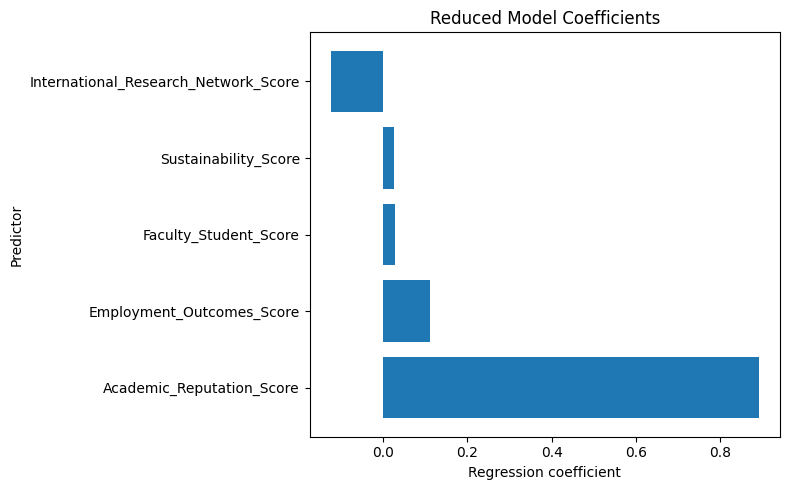

In [150]:
plt.figure(figsize=(8, 5))
plt.barh(reduced_coefficients_df["Feature"], reduced_coefficients_df["Coefficient"])
plt.xlabel("Regression coefficient")
plt.ylabel("Predictor")
plt.title("Reduced Model Coefficients")
plt.tight_layout()
plt.show()

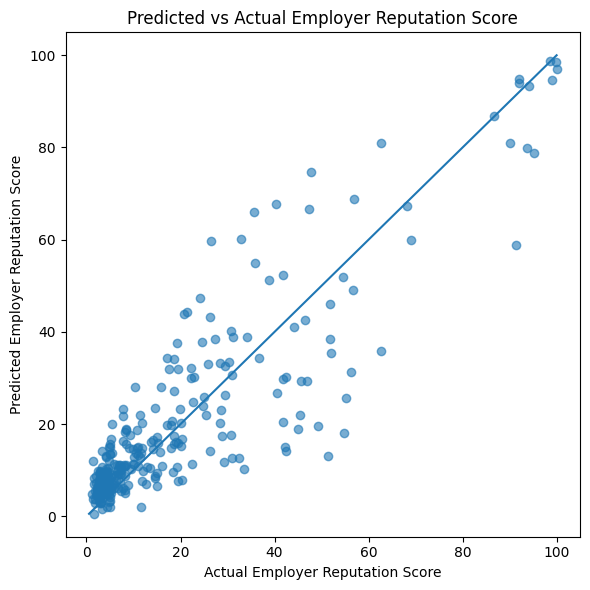

In [151]:
X_test = test_df[reduced_score_features]
y_test = test_df[target]

test_predictions = reduced_score_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_predictions, alpha=0.6)
plt.xlabel("Actual Employer Reputation Score")
plt.ylabel("Predicted Employer Reputation Score")
plt.title("Predicted vs Actual Employer Reputation Score")

min_value = min(y_test.min(), test_predictions.min())
max_value = max(y_test.max(), test_predictions.max())
plt.plot([min_value, max_value], [min_value, max_value])

plt.tight_layout()
plt.show()

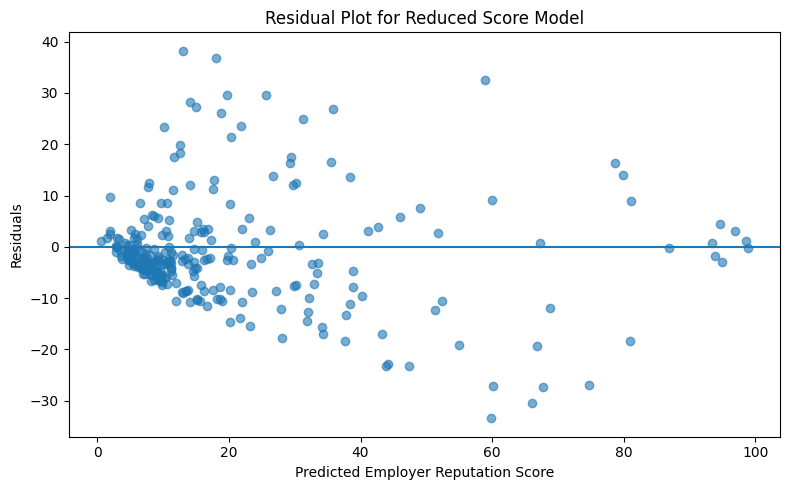

In [152]:
residuals = y_test - test_predictions

plt.figure(figsize=(8, 5))
plt.scatter(test_predictions, residuals, alpha=0.6)
plt.axhline(0)
plt.xlabel("Predicted Employer Reputation Score")
plt.ylabel("Residuals")
plt.title("Residual Plot for Reduced Score Model")
plt.tight_layout()
plt.show()

### Final modelling decision

The reduced score model was selected as the final model because it achieved similar test performance to the full score-only model while using fewer predictors. The selected predictors were Academic_Reputation_Score, International_Research_Network_Score, Employment_Outcomes_Score, Sustainability_Score, and Faculty_Student_Score. The model achieved a test R² of 0.777 and RMSE of 10.43. Academic_Reputation_Score had the largest positive coefficient, suggesting it was the strongest predictor in the reduced model. However, residuals were more dispersed for some mid- and high-scoring universities, so the model should be interpreted as a predictive approximation rather than a causal explanation.